In [10]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import timm
from torch.utils.data import DataLoader, Dataset
from timm.layers import resample_abs_pos_embed
from sklearn.metrics import roc_auc_score, accuracy_score

# Detect GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device} | Number of GPUs: {num_gpus}")

Using device: cuda | Number of GPUs: 2


In [11]:
import os

# Using the absolute path you confirmed
CACHE_PATH = "/scratch/sp7007/MoT-DAQCNN/data/quantum_datasets/breast_mnist_vit_k3_s3_custom.npz"

if os.path.exists(CACHE_PATH):
    print(f"✅ Success! Found the quantum data at: {CACHE_PATH}")
else:
    print(f"❌ Still can't find it. Is there a typo in the path?")

✅ Success! Found the quantum data at: /scratch/sp7007/MoT-DAQCNN/data/quantum_datasets/breast_mnist_vit_k3_s3_custom.npz


In [12]:
class QuantumDeiT_Base(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        # Load the powerful Base model
        self.backbone = timm.create_model('deit_base_patch16_224', pretrained=pretrained)
        self.embed_dim = self.backbone.num_features # 768
        
        # Resize Position Embeddings for our 9x9 grid
        new_pos_embed = resample_abs_pos_embed(
            self.backbone.pos_embed, 
            new_size=(9, 9), 
            num_prefix_tokens=1 
        )
        self.backbone.pos_embed = nn.Parameter(new_pos_embed)
        
        # Adapter: Projects 36 quantum channels -> 768 dimensions
        self.quantum_projection = nn.Conv2d(36, self.embed_dim, kernel_size=1)
        
        # New Head for 2 classes
        self.backbone.head = nn.Linear(self.embed_dim, num_classes)

    def forward(self, x):
        # x shape: [Batch, 36, 9, 9]
        x = self.quantum_projection(x) # [Batch, 768, 9, 9]
        
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2) # [Batch, 81, 768]
        
        # Add CLS token and Position Embeddings
        cls_token = self.backbone.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1) 
        x = x + self.backbone.pos_embed
        
        # Pass through 12 Transformer Blocks
        x = self.backbone.pos_drop(x)
        x = self.backbone.blocks(x)
        x = self.backbone.norm(x)
        
        return self.backbone.forward_head(x)

# Initialize and wrap for Multi-GPU
model = QuantumDeiT_Base(pretrained=True)
if num_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

In [13]:
from torch.utils.data import DataLoader, Dataset
import numpy as np
import torch

class QuantumFeatureDataset(Dataset):
    def __init__(self, npz_path, split='train'):
        data = np.load(npz_path, allow_pickle=True)
        self.features = torch.from_numpy(data[f'{split}_features']).float()
        self.labels = torch.from_numpy(data[f'{split}_labels']).long()
        print(f"Successfully loaded {split} set with {len(self.labels)} samples.")

    def __len__(self): 
        return len(self.labels)
    
    def __getitem__(self, idx): 
        return self.features[idx], self.labels[idx]

# Load all three splits
train_ds = QuantumFeatureDataset(CACHE_PATH, 'train')
val_ds = QuantumFeatureDataset(CACHE_PATH, 'val')
test_ds = QuantumFeatureDataset(CACHE_PATH, 'test')

# Use Batch Size 128 to take advantage of your dual A100s
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

Successfully loaded train set with 546 samples.
Successfully loaded val set with 78 samples.
Successfully loaded test set with 156 samples.


In [14]:
def set_trainable_mode(model, phase="warmup"):
    # If using DataParallel, we access the internal model via .module
    m = model.module if isinstance(model, nn.DataParallel) else model
    if phase == "warmup":
        for param in m.backbone.parameters(): param.requires_grad = False
        for param in m.backbone.head.parameters(): param.requires_grad = True
        for param in m.quantum_projection.parameters(): param.requires_grad = True
    else:
        for param in m.parameters(): param.requires_grad = True

# Settings
WARMUP_EPOCHS = 100
TOTAL_EPOCHS = 400
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)

for epoch in range(TOTAL_EPOCHS):
    if epoch == WARMUP_EPOCHS:
        set_trainable_mode(model, "finetune")
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS - WARMUP_EPOCHS)

    model.train()
    correct, total = 0, 0
    for feats, lbls in train_loader:
        feats, lbls = feats.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(feats)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        correct += (outputs.argmax(1) == lbls).sum().item()
        total += lbls.size(0)
    
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        model.eval()
        v_correct = 0
        with torch.no_grad():
            for feats, lbls in val_loader:
                feats, lbls = feats.to(device), lbls.to(device)
                v_correct += (model(feats).argmax(1) == lbls).sum().item()
        print(f"Epoch {epoch+1} | Train Acc: {100*correct/total:.2f}% | Val Acc: {100*v_correct/len(val_ds):.2f}%")

Epoch 10 | Train Acc: 73.08% | Val Acc: 73.08%
Epoch 20 | Train Acc: 78.39% | Val Acc: 82.05%
Epoch 30 | Train Acc: 88.83% | Val Acc: 87.18%
Epoch 40 | Train Acc: 92.31% | Val Acc: 87.18%
Epoch 50 | Train Acc: 94.51% | Val Acc: 89.74%
Epoch 60 | Train Acc: 94.51% | Val Acc: 89.74%
Epoch 70 | Train Acc: 95.42% | Val Acc: 92.31%
Epoch 80 | Train Acc: 99.45% | Val Acc: 85.90%
Epoch 90 | Train Acc: 97.07% | Val Acc: 88.46%
Epoch 100 | Train Acc: 99.82% | Val Acc: 88.46%
Epoch 110 | Train Acc: 99.82% | Val Acc: 88.46%
Epoch 120 | Train Acc: 99.82% | Val Acc: 88.46%
Epoch 130 | Train Acc: 99.82% | Val Acc: 88.46%
Epoch 140 | Train Acc: 100.00% | Val Acc: 87.18%
Epoch 150 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 160 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 170 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 180 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 190 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 200 | Train Acc: 100.00% | Val Acc: 88.46%
Epoch 210 | Train Acc: 100.00% | Val Acc: 

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc, classification_report)

# Set model to evaluation mode
model.eval()

y_true = []
y_probs = []
y_preds = []

print("Evaluating on Test Set...")
with torch.no_grad():
    for feats, lbls in test_loader:
        feats = feats.to(device)
        
        # Forward pass
        logits = model(feats)
        
        # Get probabilities for the 'Malignant' class (index 1)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)
        
        # Append to lists (moving to CPU)
        y_true.extend(lbls.numpy())
        y_probs.extend(probs.cpu().numpy())
        y_preds.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_preds = np.array(y_preds)

# Calculate Core Metrics
final_acc = accuracy_score(y_true, y_preds)
final_auc = roc_auc_score(y_true, y_probs)

print(f"\n" + "="*30)
print(f"FINAL TEST ACCURACY: {final_acc*100:.2f}%")
print(f"FINAL TEST AUC:      {final_auc:.4f}")
print("="*30 + "\n")
print(classification_report(y_true, y_preds, target_names=['Benign', 'Malignant']))

Evaluating on Test Set...

FINAL TEST ACCURACY: 80.13%
FINAL TEST AUC:      0.8310

              precision    recall  f1-score   support

      Benign       0.64      0.60      0.62        42
   Malignant       0.85      0.88      0.87       114

    accuracy                           0.80       156
   macro avg       0.75      0.74      0.74       156
weighted avg       0.80      0.80      0.80       156



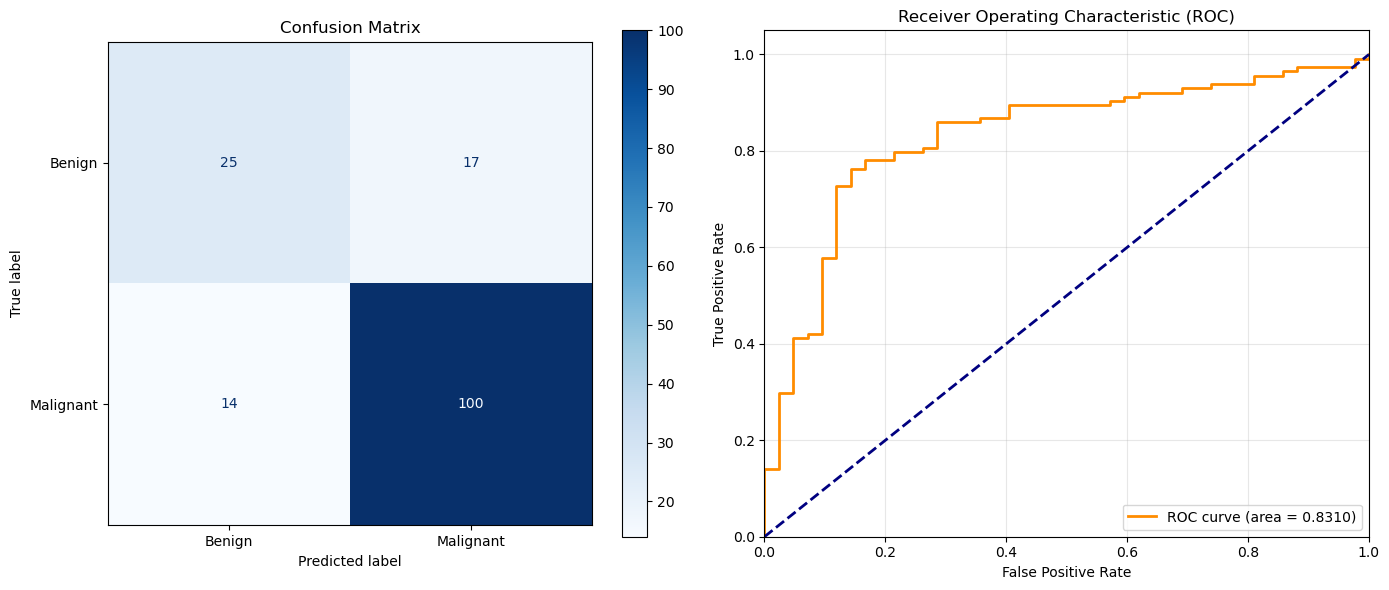

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', ax=ax[0], values_format='d')
ax[0].set_title('Confusion Matrix')

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc_val = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()